In [ ]:
# @title 安装环境缺失库
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.9 MB/s eta 0:00:00


Using device: cuda
Initializing ForecastLoader (val mode)...
Fetching one batch of data...
y_context shape: torch.Size([1, 38, 241, 397])
y_target shape: torch.Size([1, 397, 241, 5])


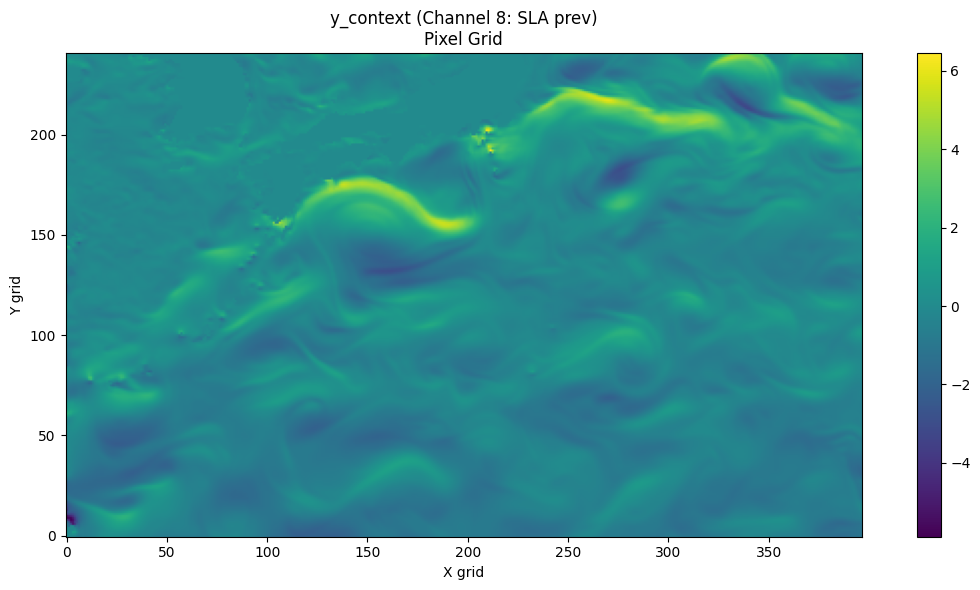

<Figure size 640x480 with 0 Axes>

In [ ]:
#  @title 预报模型loader代码测试
import os
# 切换到指定路径
%matplotlib inline
os.chdir('/content/drive/MyDrive/OM_major_revision/high_resolution_study/')
%run loader.py

In [ ]:
#  @title 预报模型model代码测试
import os
# 切换到指定路径
%matplotlib inline
os.chdir('/content/drive/MyDrive/OM_major_revision/high_resolution_study/')
%run model.py

Testing on device: cuda
Initializing Loader and Model...
Fetching batch...
Input y_context shape: torch.Size([2, 38, 241, 397])
Input y_target shape:  torch.Size([2, 397, 241, 5])
Running Model Forward Pass...

--- Success! ---
Forward output shape: torch.Size([2, 397, 241, 5])
Size Flow Check: PASSED (Output matches Target)


In [ ]:
# @title 西太高分辨率海表预报模型多变量训练(含有未来通量)
import os

# 切换到指定路径
os.chdir('/content/drive/MyDrive/OM_major_revision/high_resolution_study/')
!python3 /content/drive/MyDrive/OM_major_revision/high_resolution_study/train_module.py \
    --output_dir ./model_train_withfutureflux_xitai \
    --in_channels 38 \
    --out_channels 5 \
    --int_channels 256 \
    --lead_time 1 \
    --lr 1e-3 \
    --batch_size 16 \
    --start_ind 0 \
    --end_ind 5 \
    --epoch 150 \
    --weight_per_variable 0

100% 433/433 [03:16<00:00,  2.20batch/s, loss=0.847]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.852]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.814]
100% 433/433 [03:15<00:00,  2.21batch/s, loss=0.738]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.723]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.689]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.61]
100% 433/433 [03:15<00:00,  2.21batch/s, loss=0.57]
100% 433/433 [03:16<00:00,  2.20batch/s, loss=0.6]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.511]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.533]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.533]
100% 433/433 [03:15<00:00,  2.21batch/s, loss=0.548]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.517]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.499]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.485]
100% 433/433 [03:15<00:00,  2.21batch/s, loss=0.503]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.46]
100% 433/433 [03:16<00:00,  2.21batch/s, loss=0.458

In [ ]:
# @title 模型推理
import os

# 切换到指定路径
os.chdir('/content/drive/MyDrive/OM_major_revision/high_resolution_study/')
!python3 inference_realtime_bulk_flux.py

Dataset mode           : val
ERA5 year              : 2019
ERA5 path              : ./high_resolution_data/era5_raw/era5_2019_daily_interp_to_GLORYS_122E155E_18N38N.nc
Number of dates        : 365
ERA5 ntime             : 365
Lead days              : 10
Number of cases        : 354
First init date        : 2019-01-02
Last init date         : 2019-12-21
Input channels         : 38
Online bulk flux       : True
Save predictions       : True
Prediction dir         : /content/drive/MyDrive/OM_major_revision/high_resolution_study/val_2019_10day_rmse_xitai_livebulk/predictions_by_case
Forecasting all cases with live bulk flux: 100% 354/354 [2:21:32<00:00, 23.99s/it]

完成：实时计算 bulk flux 的 10 天递推评估。
RMSE npz saved to     : /content/drive/MyDrive/OM_major_revision/high_resolution_study/val_2019_10day_rmse_xitai_livebulk/val_10day_rmse_all_cases_livebulk.npz
RMSE csv saved to     : /content/drive/MyDrive/OM_major_revision/high_resolution_study/val_2019_10day_rmse_xitai_livebulk/val_10day_rmse_cur

In [ ]:
# @title 模型推理
import os

# 切换到指定路径
os.chdir('/content/drive/MyDrive/OM_major_revision/high_resolution_study/')
!python3 multfile_forecast_real_from_GLO12v4_ERA5_nc.py

Batch GLO12v4 + ERA5 real forecast
Input dir       : /content/drive/MyDrive/OM_major_revision/high_resolution_study/high_resolution_data/GLO12v4
Output dir      : /content/drive/MyDrive/OM_major_revision/high_resolution_study/GLO12v4_output_total
Checkpoint      : /content/drive/MyDrive/OM_major_revision/high_resolution_study/model_train_withfutureflux_xitai/epoch_126
Data path       : /content/drive/MyDrive/OM_major_revision/high_resolution_study/high_resolution_data
Lead days       : 10
Device          : cuda
Number of files : 35
Skip existing   : True
  0001: GLO12v4_ERA5_20260412_12days_on_target_grid.nc
  0002: GLO12v4_ERA5_20260413_12days_on_target_grid.nc
  0003: GLO12v4_ERA5_20260414_12days_on_target_grid.nc
  0004: GLO12v4_ERA5_20260416_12days_on_target_grid.nc
  0005: GLO12v4_ERA5_20260417_12days_on_target_grid.nc
  0006: GLO12v4_ERA5_20260418_12days_on_target_grid.nc
  0007: GLO12v4_ERA5_20260419_12days_on_target_grid.nc
  0008: GLO12v4_ERA5_20260420_12days_on_target_grid.nc

In [ ]:
# @title 西太高分辨率海表预报模型多变量训练(含有未来通量)
import os

# 切换到指定路径
os.chdir('/content/drive/MyDrive/OM_major_revision/high_resolution_study/')
!python3 /content/drive/MyDrive/OM_major_revision/high_resolution_study/train_module.py \
    --output_dir ./model_train_withfutureflux_xitai_new \
    --in_channels 38 \
    --out_channels 5 \
    --int_channels 256 \
    --lead_time 1 \
    --lr 1e-3 \
    --batch_size 16 \
    --start_ind 0 \
    --end_ind 5 \
    --epoch 150 \
    --weight_per_variable 0

100% 433/433 [03:19<00:00,  2.17batch/s, loss=0.932]
100% 433/433 [03:17<00:00,  2.20batch/s, loss=0.859]
100% 433/433 [03:17<00:00,  2.19batch/s, loss=0.793]
100% 433/433 [03:17<00:00,  2.19batch/s, loss=0.683]
100% 433/433 [03:17<00:00,  2.20batch/s, loss=0.678]
100% 433/433 [03:16<00:00,  2.20batch/s, loss=0.612]
100% 433/433 [03:17<00:00,  2.19batch/s, loss=0.554]
100% 433/433 [03:17<00:00,  2.19batch/s, loss=0.514]
100% 433/433 [03:17<00:00,  2.19batch/s, loss=0.508]
100% 433/433 [03:17<00:00,  2.20batch/s, loss=0.549]
100% 433/433 [03:16<00:00,  2.20batch/s, loss=0.462]
100% 433/433 [03:17<00:00,  2.19batch/s, loss=0.47]
100% 433/433 [03:16<00:00,  2.20batch/s, loss=0.494]
100% 433/433 [03:16<00:00,  2.20batch/s, loss=0.462]
100% 433/433 [03:17<00:00,  2.20batch/s, loss=0.463]
100% 433/433 [03:17<00:00,  2.20batch/s, loss=0.415]
100% 433/433 [03:17<00:00,  2.19batch/s, loss=0.418]
100% 433/433 [03:17<00:00,  2.19batch/s, loss=0.434]
100% 433/433 [03:17<00:00,  2.19batch/s, loss=0

In [ ]:
# @title 模型推理
import os

# 切换到指定路径
os.chdir('/content/drive/MyDrive/OM_major_revision/high_resolution_study/')
!python3 inference_realtime_bulk_flux.py

Dataset mode           : val
ERA5 year              : 2019
ERA5 path              : ./high_resolution_data/era5_raw/era5_2019_daily_interp_to_GLORYS_122E155E_18N38N.nc
Number of dates        : 365
ERA5 ntime             : 365
Lead days              : 10
Number of cases        : 354
First init date        : 2019-01-02
Last init date         : 2019-12-21
Input channels         : 38
Online bulk flux       : True
Save predictions       : True
Prediction dir         : /content/drive/MyDrive/OM_major_revision/high_resolution_study/val_2019_10day_rmse_xitai_livebulk_new/predictions_by_case
Forecasting all cases with live bulk flux: 100% 354/354 [2:16:22<00:00, 23.11s/it]

完成：实时计算 bulk flux 的 10 天递推评估。
RMSE npz saved to     : /content/drive/MyDrive/OM_major_revision/high_resolution_study/val_2019_10day_rmse_xitai_livebulk_new/val_10day_rmse_all_cases_livebulk.npz
RMSE csv saved to     : /content/drive/MyDrive/OM_major_revision/high_resolution_study/val_2019_10day_rmse_xitai_livebulk_new/val_10